# 📱 Smartphones 2025–2026: Value-for-Money Analysis

**Author:** Rentaro Yamamoto
**Data Source:** Smartprix (Web Scraped – April 2026)  
**Dataset Size:** 997 devices | 26 features  

---

## Project Overview

This notebook performs end-to-end analysis of the Smartprix smartphone dataset covering **Budget → Flagship** segments. We will:

1. **Explore & Clean** the data (EDA + missing value handling)
2. **Visualise** key trends — brands, price categories, spec distributions
3. **Answer Business Questions** — the Premium Gap, Brand Wars, Value Kings
4. **Build a Price Prediction Model** (Random Forest + Linear Regression)
5. **Evaluate & Interpret** with feature importance and residual analysis


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = 'viridis'
CAT_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load & Inspect the Dataset

In [2]:
df = pd.read_csv('smartprix_smartphones_april_2026.csv')

print(f'Shape : {df.shape}')
print(f'Rows  : {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head()

Shape : (997, 26)
Rows  : 997  |  Columns: 26


,brand_name,model,price_category,price,spec_score,vfm_score,vfm_label,has_5G,has_NFC,has_IR,...,battery_capacity(mAh),fast_charging(W),charging_ratio,charging_speed_type,screen_size,refresh_rate,rear_camera,front_camera,rear_camera_count,os
0,oneplus,OnePlus Nord 6,Premium,38999,81,0.906828,Average Value,True,True,True,...,9000.0,80.0,112.500000,Standard,6.78,165.0,50.0,32.0,2,Android v16
1,samsung,Samsung Galaxy S25 Ultra,Flagship,110000,89,0.658517,Average Value,True,True,False,...,5000.0,45.0,111.111111,Standard,6.90,120.0,200.0,12.0,4,Android v15
2,vivo,Vivo T5 Pro,Mid-Range,29999,72,1.522389,Value King,True,False,True,...,9020.0,90.0,100.222222,Standard,6.80,120.0,50.0,50.0,3,Android v16
3,samsung,Samsung Galaxy S25 FE,Premium,50743,77,0.282124,Average Value,True,True,False,...,4900.0,45.0,108.888889,Standard,6.70,120.0,50.0,12.0,3,Android v16
4,vivo,Vivo T5x 5G,Mid-Range,18999,66,0.478615,Average Value,True,False,True,...,7200.0,44.0,163.636364,Standard,6.76,120.0,50.0,32.0,2,Android v16


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             997 non-null    object 
 1   model                  997 non-null    object 
 2   price_category         997 non-null    object 
 3   price                  997 non-null    int64  
 4   spec_score             997 non-null    int64  
 5   vfm_score              997 non-null    float64
 6   vfm_label              997 non-null    object 
 7   has_5G                 997 non-null    bool   
 8   has_NFC                997 non-null    bool   
 9   has_IR                 997 non-null    bool   
 10  processor_brand        996 non-null    object 
 11  processor_name         997 non-null    object 
 12  num_core               980 non-null    float64
 13  processor_speed        862 non-null    float64
 14  ram                    997 non-null    float64
 15  memory

In [4]:
df.describe()

,price,spec_score,vfm_score,num_core,processor_speed,ram,memory,battery_capacity(mAh),fast_charging(W),charging_ratio,screen_size,refresh_rate,rear_camera,front_camera,rear_camera_count
count,997.000000,997.000000,9.970000e+02,980.000000,862.000000,997.000000,997.000000,997.000000,941.000000,941.000000,997.000000,948.000000,981.000000,979.000000,997.000000
mean,38153.403210,66.827482,3.420868e-16,7.964286,2.803109,8.600802,209.853561,5910.256770,71.273114,143.846701,6.799198,123.291139,61.993068,22.706946,2.345035
std,41182.544768,12.380527,9.984928e-01,0.482323,0.666099,3.146541,114.782038,1206.023264,365.592799,98.418805,1.875693,16.420801,43.120843,15.485954,0.654999
min,4999.000000,23.000000,-4.914255e+00,1.000000,1.300000,2.000000,1.000000,6.200000,10.000000,0.625000,4.000000,90.000000,8.000000,5.000000,1.000000
25%,16799.000000,58.000000,-6.549316e-01,8.000000,2.400000,6.000000,128.000000,5000.000000,33.000000,75.000000,6.670000,120.000000,50.000000,10.000000,2.000000
50%,25999.000000,66.000000,1.176810e-01,8.000000,2.500000,8.000000,256.000000,5800.000000,45.000000,112.500000,6.740000,120.000000,50.000000,16.000000,2.000000
75%,42990.000000,76.000000,6.525773e-01,8.000000,3.200000,12.000000,256.000000,6580.000000,80.000000,170.000000,6.780000,120.000000,50.000000,32.000000,3.000000
max,489990.000000,98.000000,2.392201e+00,10.000000,4.740000,24.000000,512.000000,13080.000000,11200.000000,600.000000,48.000000,240.000000,200.000000,60.000000,4.000000


## 3. Missing Value Analysis

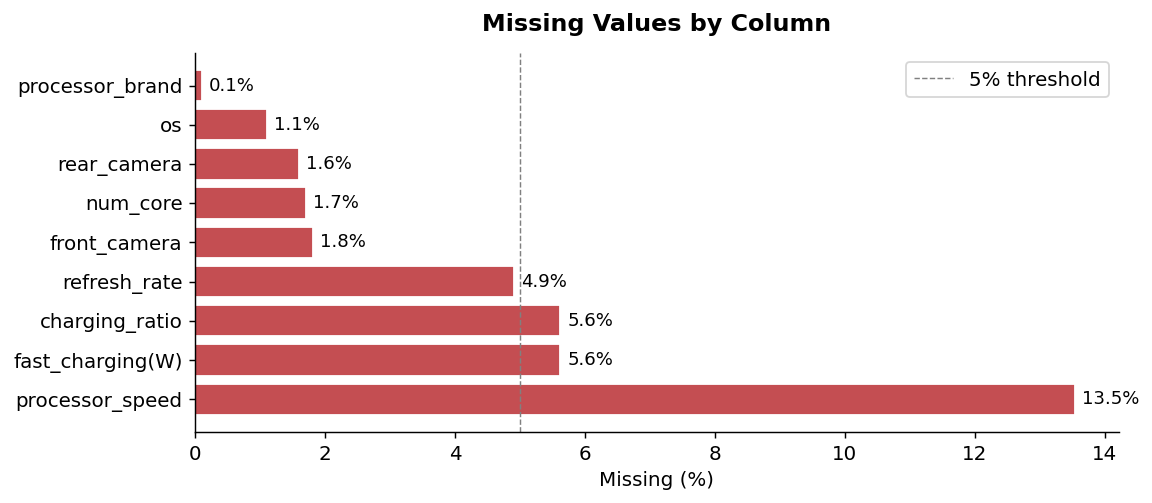

                  missing    pct
processor_speed       135  13.54
fast_charging(W)       56   5.62
charging_ratio         56   5.62
refresh_rate           49   4.91
front_camera           18   1.81
num_core               17   1.71
rear_camera            16   1.60
os                     11   1.10
processor_brand         1   0.10


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing.index, pct.values, color='#C44E52', edgecolor='white')
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in pct.values], padding=4, fontsize=10)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column', fontweight='bold', pad=12)
ax.axvline(5, linestyle='--', color='grey', linewidth=0.8, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(pd.DataFrame({'missing': missing, 'pct': pct}))

## 4. Data Cleaning & Feature Engineering

In [6]:
df_clean = df.copy()

# ── 4.1  Fill numerical columns with median per price category ────────────────
num_cols_to_fill = ['processor_speed', 'fast_charging(W)', 'charging_ratio',
                    'refresh_rate', 'rear_camera', 'front_camera', 'num_core']

for col in num_cols_to_fill:
    df_clean[col] = df_clean.groupby('price_category')[col].transform(
        lambda x: x.fillna(x.median())
    )

# ── 4.2  Fill categorical columns with mode ───────────────────────────────────
df_clean['processor_brand'] = df_clean['processor_brand'].fillna(
    df_clean['processor_brand'].mode()[0]
)
df_clean['os'] = df_clean['os'].fillna('Android v15')

# ── 4.3  Re-compute charging_ratio where still NaN ───────────────────────────
mask = df_clean['charging_ratio'].isna()
df_clean.loc[mask, 'charging_ratio'] = (
    df_clean.loc[mask, 'battery_capacity(mAh)'] /
    df_clean.loc[mask, 'fast_charging(W)']
)

# ── 4.4  Derived features ─────────────────────────────────────────────────────
df_clean['price_inr_k'] = df_clean['price'] / 1000          # price in thousands
df_clean['ram_to_storage'] = df_clean['ram'] / df_clean['memory']  # RAM efficiency
df_clean['os_version'] = (
    df_clean['os'].str.extract(r'(\d+\.?\d*)').astype(float)
)

# ── 4.5  Category ordering ────────────────────────────────────────────────────
CAT_ORDER = ['Budget', 'Mid-Range', 'Premium', 'Flagship']
df_clean['price_category'] = pd.Categorical(
    df_clean['price_category'], categories=CAT_ORDER, ordered=True
)

print('Missing after cleaning:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print(f'\nDataset ready: {df_clean.shape[0]} rows × {df_clean.shape[1]} cols ✅')

Missing after cleaning:
Series([], dtype: int64)

Dataset ready: 997 rows × 29 cols ✅


## 5. Exploratory Data Analysis (EDA)

### 5.1 Price Category Distribution

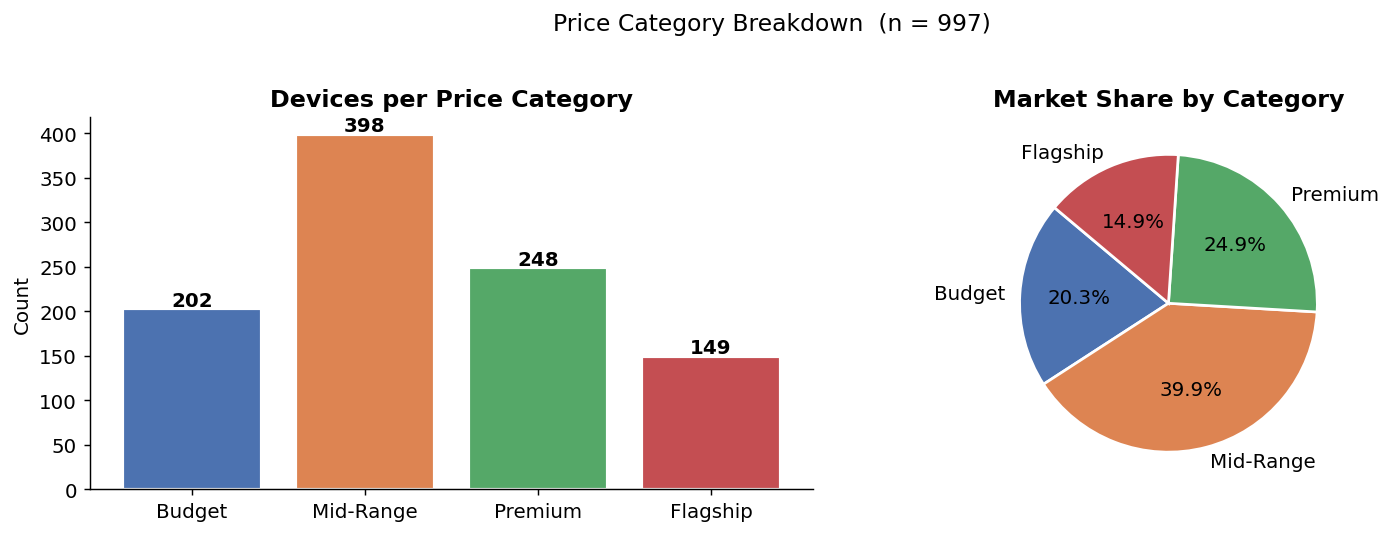

In [7]:
cat_counts = df_clean['price_category'].value_counts()[CAT_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(CAT_ORDER, cat_counts.values, color=CAT_COLORS, edgecolor='white', linewidth=1.2)
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 4, str(v), ha='center', fontweight='bold')
axes[0].set_title('Devices per Price Category', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie
axes[1].pie(cat_counts.values, labels=CAT_ORDER, colors=CAT_COLORS,
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Market Share by Category', fontweight='bold')

plt.suptitle('Price Category Breakdown  (n = 997)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Brand Landscape

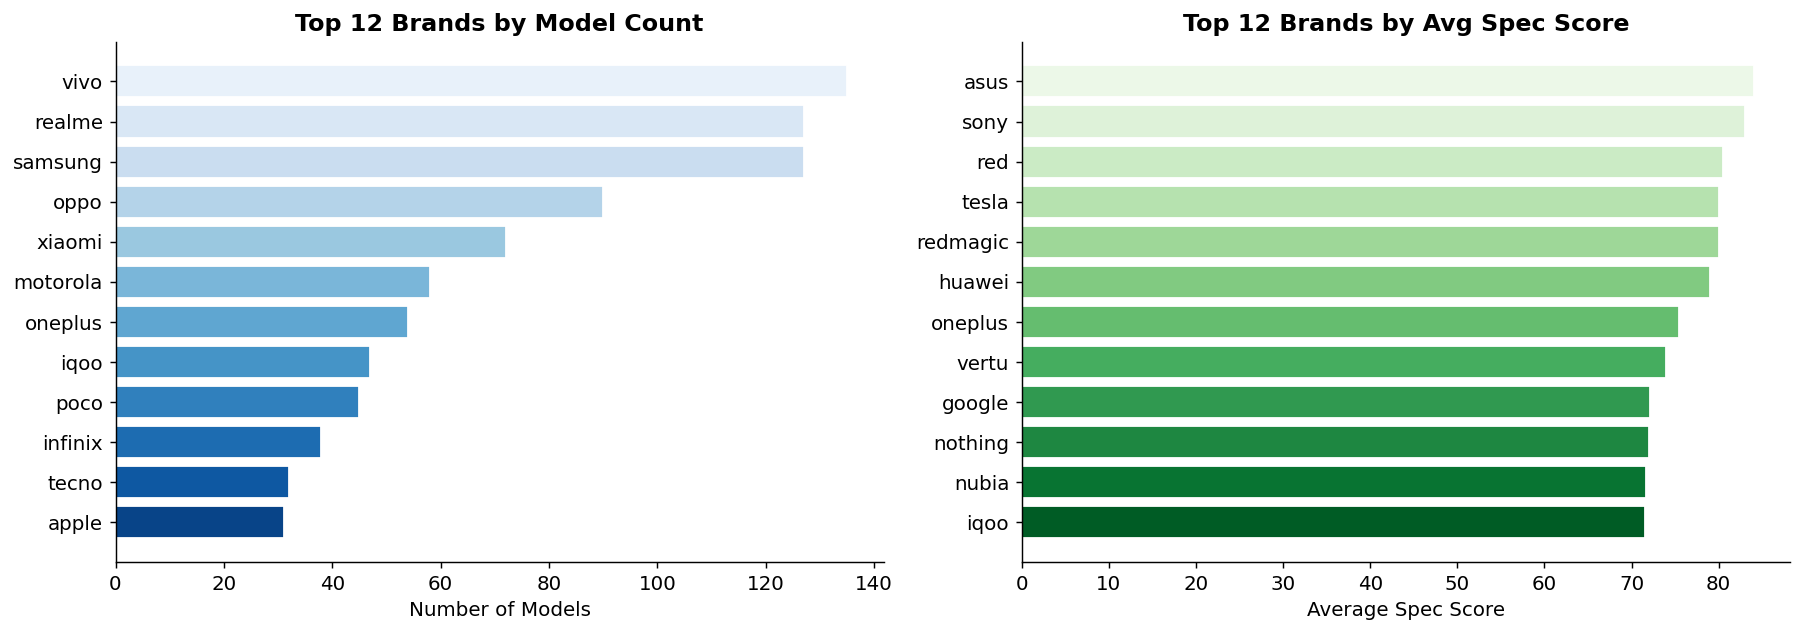

In [8]:
top_brands = df_clean['brand_name'].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total devices
axes[0].barh(top_brands.index[::-1], top_brands.values[::-1],
             color=sns.color_palette('Blues_r', len(top_brands)), edgecolor='white')
axes[0].set_xlabel('Number of Models')
axes[0].set_title('Top 12 Brands by Model Count', fontweight='bold')

# Avg spec score per brand
avg_spec = (df_clean.groupby('brand_name')['spec_score']
              .mean().sort_values(ascending=False).head(12))
axes[1].barh(avg_spec.index[::-1], avg_spec.values[::-1],
             color=sns.color_palette('Greens_r', 12), edgecolor='white')
axes[1].set_xlabel('Average Spec Score')
axes[1].set_title('Top 12 Brands by Avg Spec Score', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.3 Price Distribution Across Categories

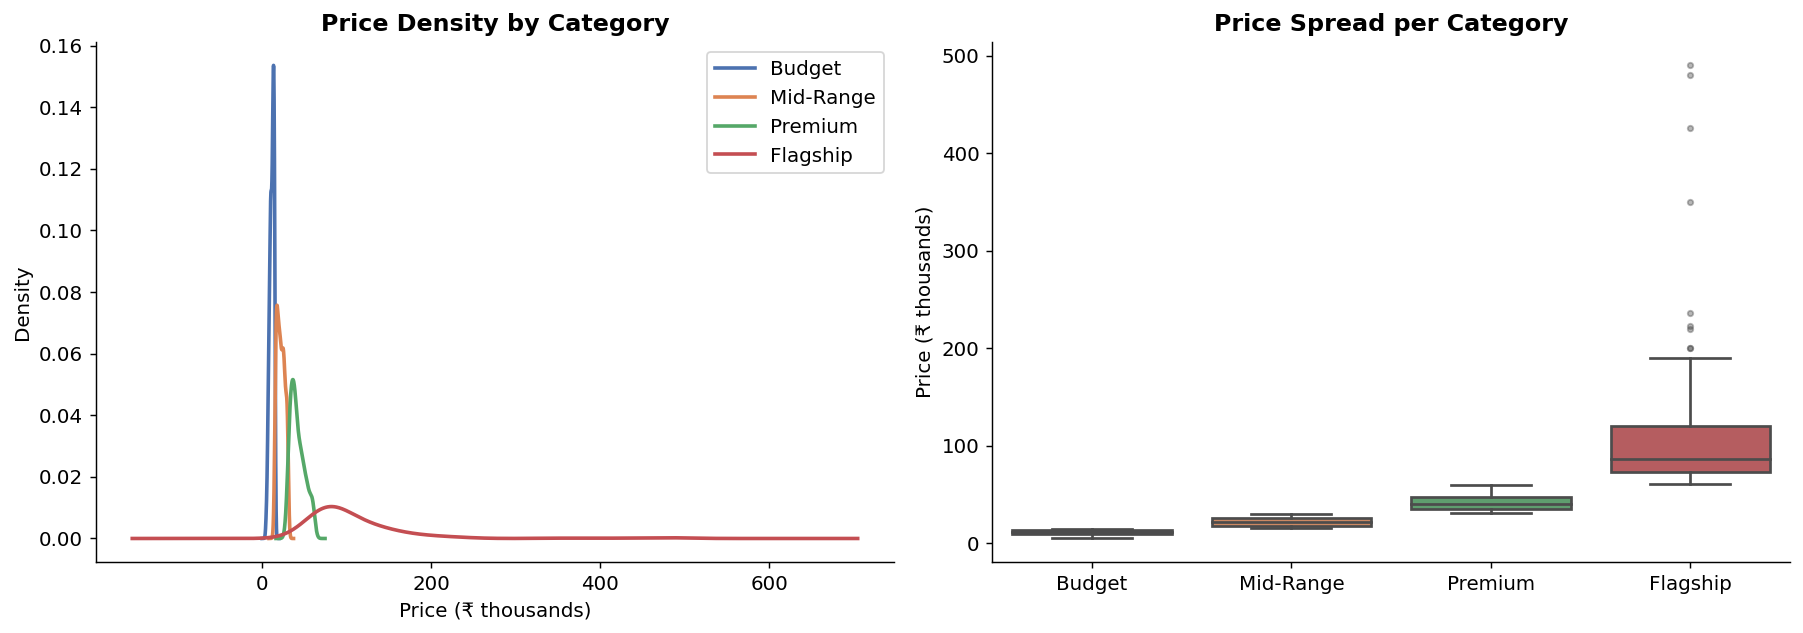

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
for cat, col in zip(CAT_ORDER, CAT_COLORS):
    subset = df_clean[df_clean['price_category'] == cat]['price'] / 1000
    subset.plot.kde(ax=axes[0], label=cat, color=col, linewidth=2)
axes[0].set_xlabel('Price (₹ thousands)')
axes[0].set_title('Price Density by Category', fontweight='bold')
axes[0].legend()

# Box plot
sns.boxplot(
    data=df_clean, x='price_category', y='price_inr_k',
    order=CAT_ORDER, palette=CAT_COLORS,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
    ax=axes[1]
)
axes[1].set_xlabel('')
axes[1].set_ylabel('Price (₹ thousands)')
axes[1].set_title('Price Spread per Category', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.4 VFM Label Distribution

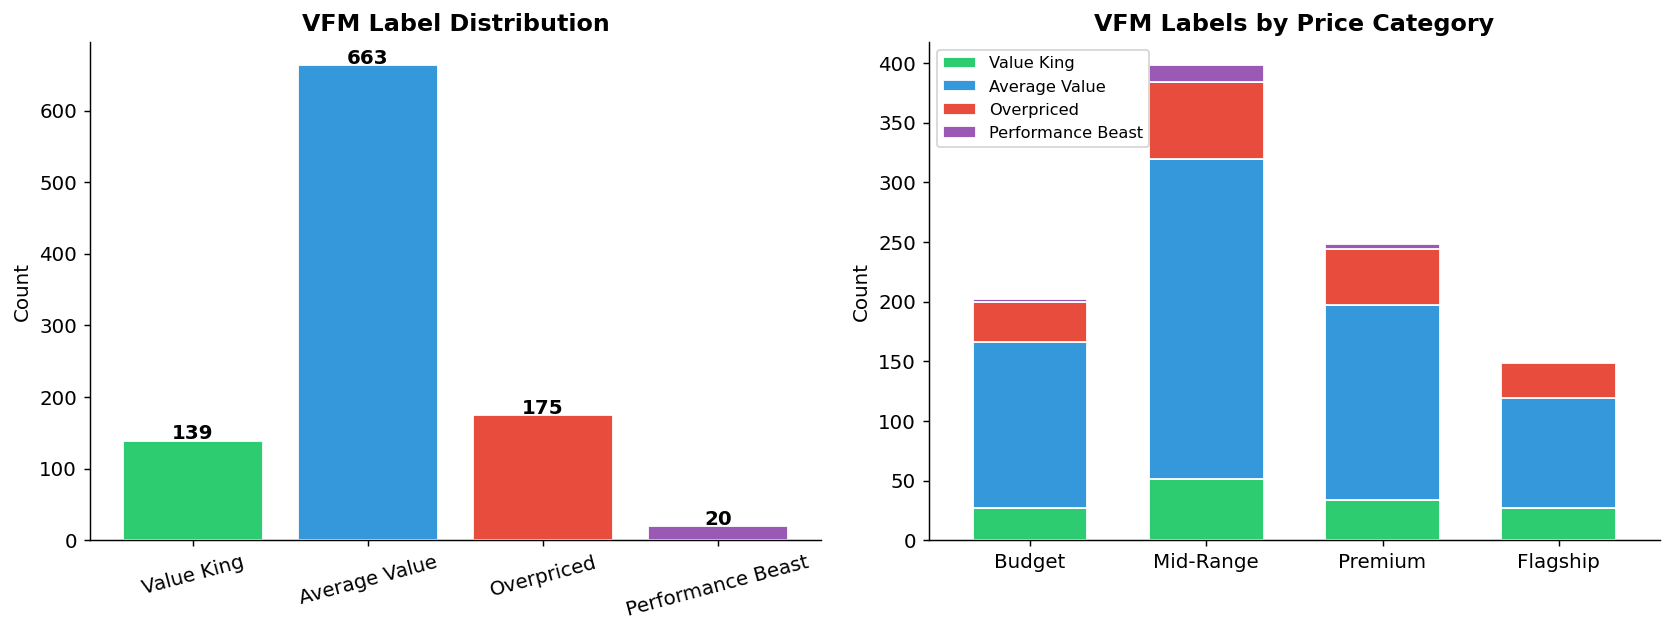

In [10]:
VFM_ORDER = ['Value King', 'Average Value', 'Overpriced', 'Performance Beast']
VFM_COLORS = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

vfm_counts = df_clean['vfm_label'].value_counts().reindex(VFM_ORDER, fill_value=0)
axes[0].bar(vfm_counts.index, vfm_counts.values, color=VFM_COLORS, edgecolor='white')
for i, v in enumerate(vfm_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[0].set_title('VFM Label Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# VFM labels stacked by category
vfm_cat = (df_clean.groupby(['price_category', 'vfm_label'])
             .size().unstack(fill_value=0))
vfm_cat = vfm_cat.reindex(columns=VFM_ORDER, fill_value=0)
vfm_cat.plot(kind='bar', ax=axes[1], color=VFM_COLORS, edgecolor='white',
             stacked=True, width=0.65)
axes[1].set_title('VFM Labels by Price Category', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

### 5.5 Hardware Spec Heatmap (Median per Category)

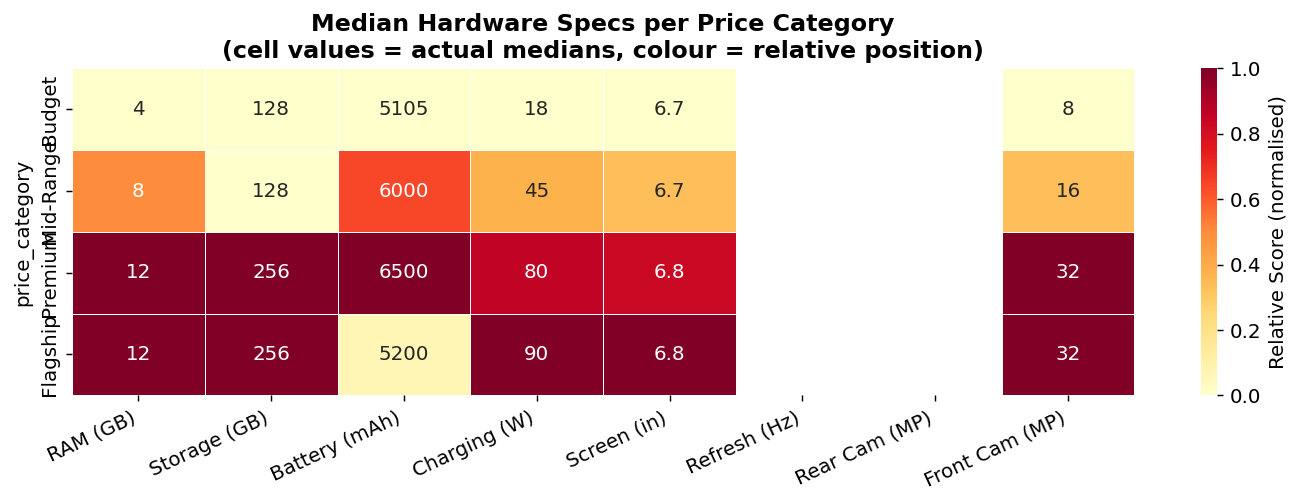

In [11]:
spec_cols = ['ram', 'memory', 'battery_capacity(mAh)',
             'fast_charging(W)', 'screen_size', 'refresh_rate',
             'rear_camera', 'front_camera']

heatmap_df = (df_clean.groupby('price_category')[spec_cols]
                .median().reindex(CAT_ORDER))

# Normalise across categories (0–1) so all specs share the same colour scale
heatmap_norm = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min())

pretty_labels = ['RAM (GB)', 'Storage (GB)', 'Battery (mAh)',
                 'Charging (W)', 'Screen (in)', 'Refresh (Hz)',
                 'Rear Cam (MP)', 'Front Cam (MP)']

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_df.round(1),
    fmt='g',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Relative Score (normalised)'}
)
ax.set_xticklabels(pretty_labels, rotation=25, ha='right')
ax.set_title('Median Hardware Specs per Price Category\n(cell values = actual medians, colour = relative position)', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Deep-Dive: Business Questions

### 6.1 The Premium Gap — Does Price = Value?

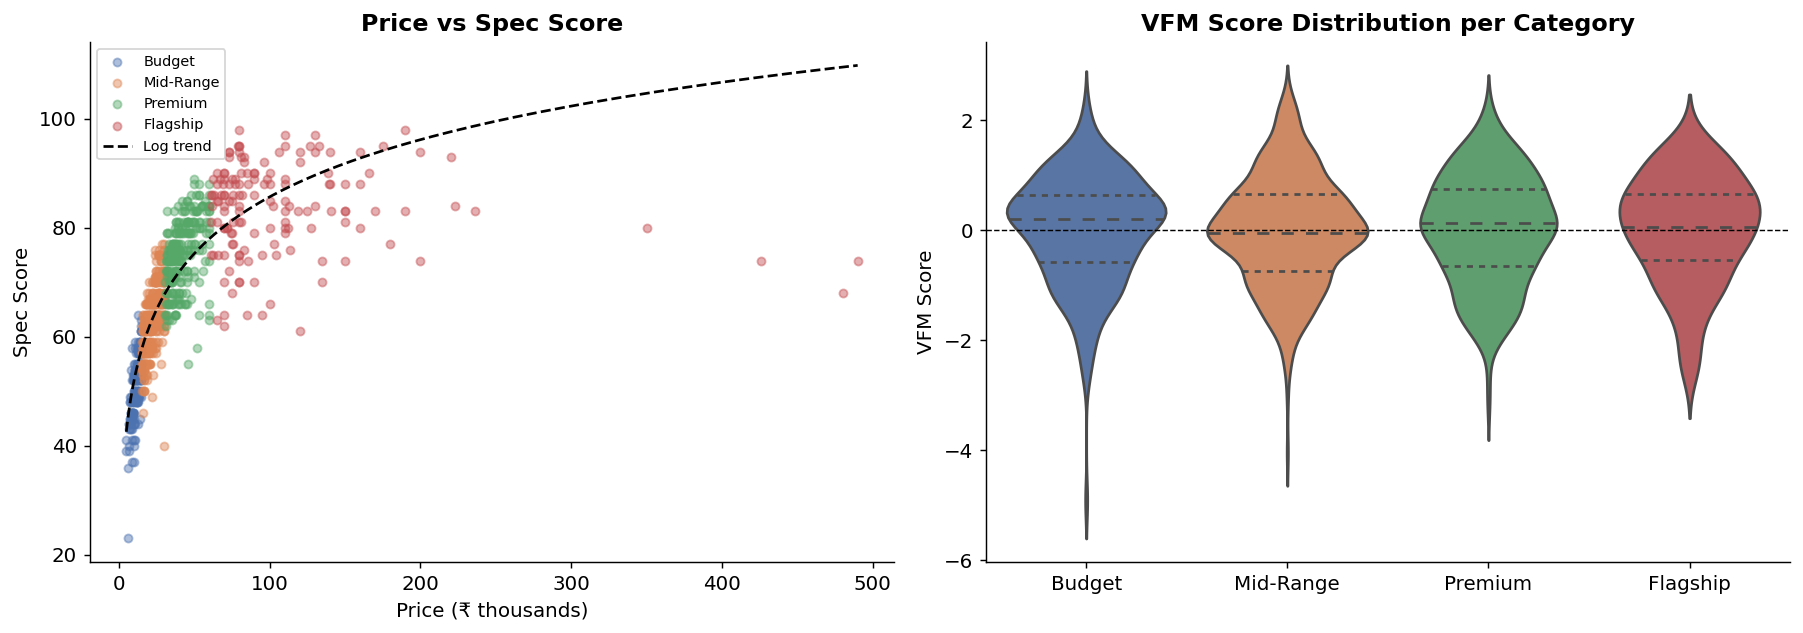

                median_price  median_spec  median_vfm  value_kings_pct  price_multiplier  spec_multiplier
price_category                                                                                           
Budget               11999.0         52.5        0.20            13.37              1.00             1.00
Mid-Range            21999.0         63.0       -0.04            12.81              1.83             1.20
Premium              39999.0         76.0        0.13            13.71              3.33             1.45
Flagship             85999.0         84.0        0.06            18.12              7.17             1.60


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter: price vs spec_score coloured by category ─────────────────────────
for cat, col in zip(CAT_ORDER, CAT_COLORS):
    subset = df_clean[df_clean['price_category'] == cat]
    axes[0].scatter(subset['price_inr_k'], subset['spec_score'],
                    alpha=0.45, s=20, color=col, label=cat)

# Trend line (log scale often linear for price)
x = np.log1p(df_clean['price_inr_k'])
y = df_clean['spec_score']
coef = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 300)
axes[0].plot(np.expm1(xline), np.polyval(coef, xline),
             'k--', linewidth=1.5, label='Log trend')
axes[0].set_xlabel('Price (₹ thousands)')
axes[0].set_ylabel('Spec Score')
axes[0].set_title('Price vs Spec Score', fontweight='bold')
axes[0].legend(fontsize=8)

# ── VFM score vs price category ───────────────────────────────────────────────
sns.violinplot(
    data=df_clean, x='price_category', y='vfm_score',
    order=CAT_ORDER, palette=CAT_COLORS,
    inner='quartile', ax=axes[1]
)
axes[1].set_xlabel('')
axes[1].set_ylabel('VFM Score')
axes[1].set_title('VFM Score Distribution per Category', fontweight='bold')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
summary = df_clean.groupby('price_category').agg(
    median_price=('price', 'median'),
    median_spec=('spec_score', 'median'),
    median_vfm=('vfm_score', 'median'),
    value_kings_pct=('vfm_label', lambda x: (x == 'Value King').mean() * 100)
).reindex(CAT_ORDER).round(2)
summary['price_multiplier'] = (summary['median_price'] / summary['median_price'].iloc[0]).round(2)
summary['spec_multiplier']  = (summary['median_spec']  / summary['median_spec'].iloc[0]).round(2)
print(summary.to_string())

### 6.2 Brand Wars — Mid-Range Spec Score Champions

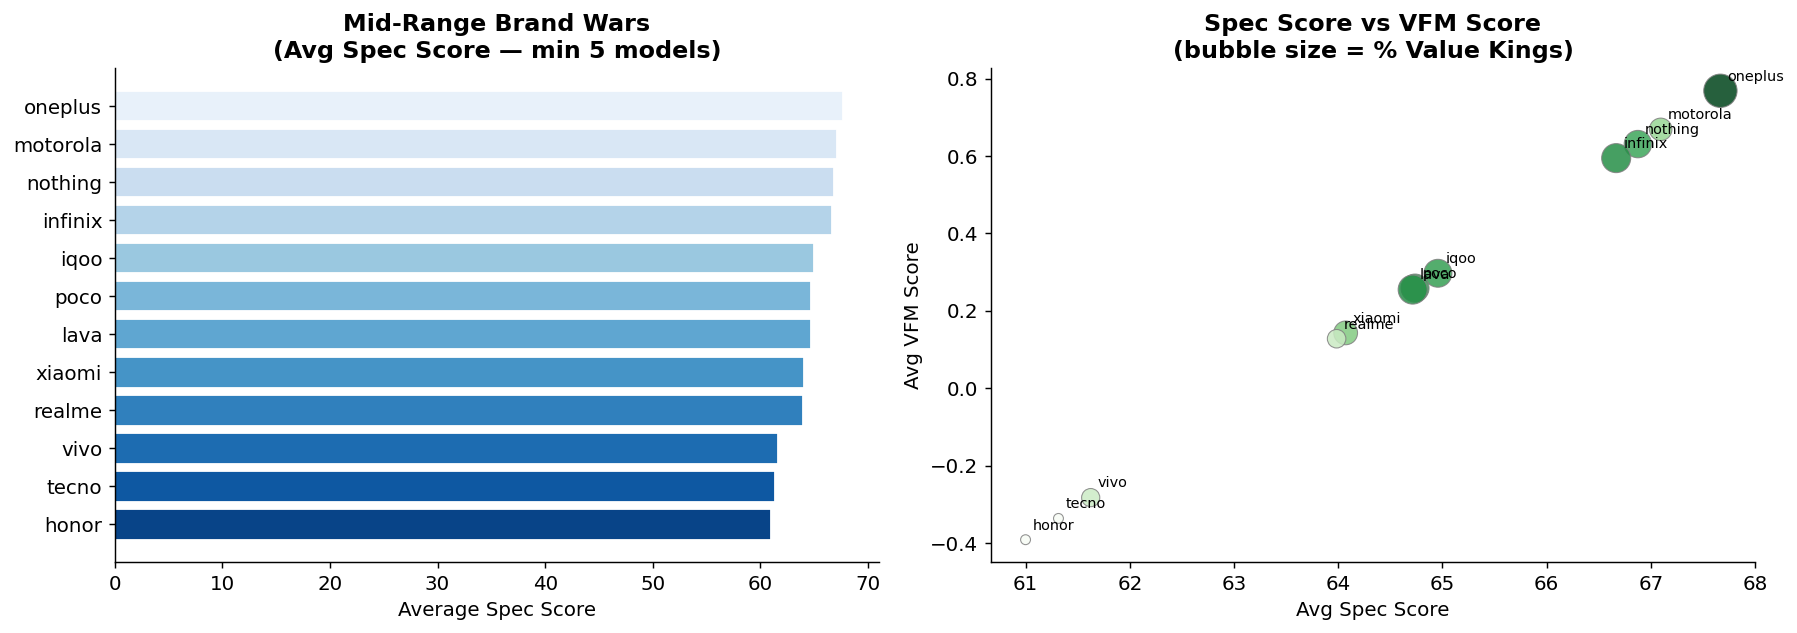

In [13]:
midrange = df_clean[df_clean['price_category'] == 'Mid-Range']

brand_stats = (
    midrange.groupby('brand_name')
    .agg(
        count=('spec_score', 'count'),
        avg_spec=('spec_score', 'mean'),
        avg_vfm=('vfm_score', 'mean'),
        value_king_pct=('vfm_label', lambda x: (x == 'Value King').mean() * 100)
    )
    .query('count >= 5')
    .sort_values('avg_spec', ascending=False)
    .head(12)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg spec score
colors_grad = sns.color_palette('Blues_r', len(brand_stats))
axes[0].barh(brand_stats.index[::-1], brand_stats['avg_spec'][::-1],
             color=colors_grad, edgecolor='white')
axes[0].set_xlabel('Average Spec Score')
axes[0].set_title('Mid-Range Brand Wars\n(Avg Spec Score — min 5 models)', fontweight='bold')

# Value King % bubble chart
axes[1].scatter(
    brand_stats['avg_spec'], brand_stats['avg_vfm'],
    s=brand_stats['value_king_pct'] * 8 + 30,
    c=brand_stats['value_king_pct'], cmap='Greens',
    edgecolors='grey', linewidth=0.6, alpha=0.85
)
for brand, row in brand_stats.iterrows():
    axes[1].annotate(brand, (row['avg_spec'], row['avg_vfm']),
                     fontsize=8, ha='left', va='bottom',
                     xytext=(4, 4), textcoords='offset points')
axes[1].set_xlabel('Avg Spec Score')
axes[1].set_ylabel('Avg VFM Score')
axes[1].set_title('Spec Score vs VFM Score\n(bubble size = % Value Kings)', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.3 Charging Technology Landscape

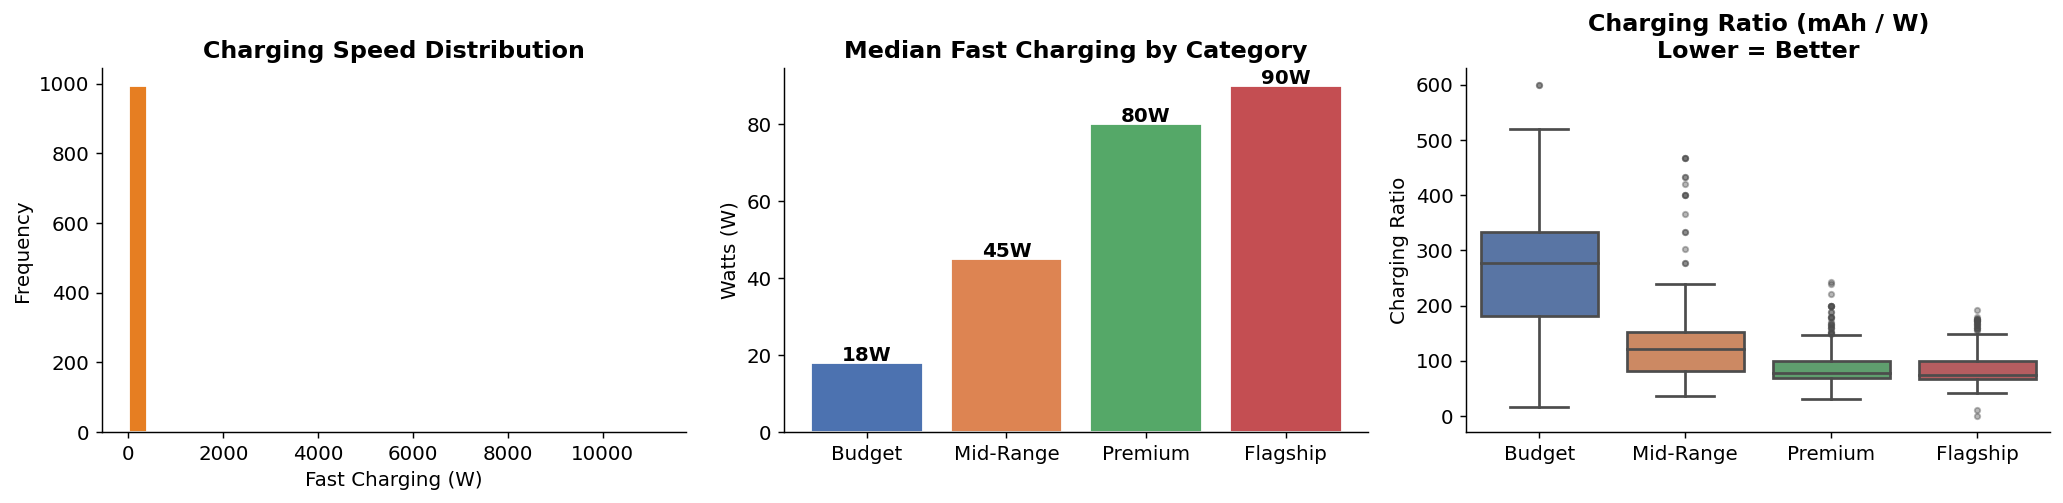

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Charging speed distribution
df_clean['fast_charging(W)'].dropna().plot.hist(
    bins=30, ax=axes[0], color='#E67E22', edgecolor='white'
)
axes[0].set_xlabel('Fast Charging (W)')
axes[0].set_title('Charging Speed Distribution', fontweight='bold')

# Median charging by category
chg_cat = df_clean.groupby('price_category')['fast_charging(W)'].median().reindex(CAT_ORDER)
axes[1].bar(CAT_ORDER, chg_cat, color=CAT_COLORS, edgecolor='white')
for i, v in enumerate(chg_cat):
    axes[1].text(i, v + 0.5, f'{v:.0f}W', ha='center', fontweight='bold')
axes[1].set_title('Median Fast Charging by Category', fontweight='bold')
axes[1].set_ylabel('Watts (W)')

# Charging ratio (battery / fast_charging) = hours to full
# Lower ratio = faster effective charging
sns.boxplot(
    data=df_clean, x='price_category', y='charging_ratio',
    order=CAT_ORDER, palette=CAT_COLORS,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
    ax=axes[2]
)
axes[2].set_title('Charging Ratio (mAh / W)\nLower = Better', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('Charging Ratio')

plt.tight_layout()
plt.show()

### 6.4 Connectivity & OS Adoption

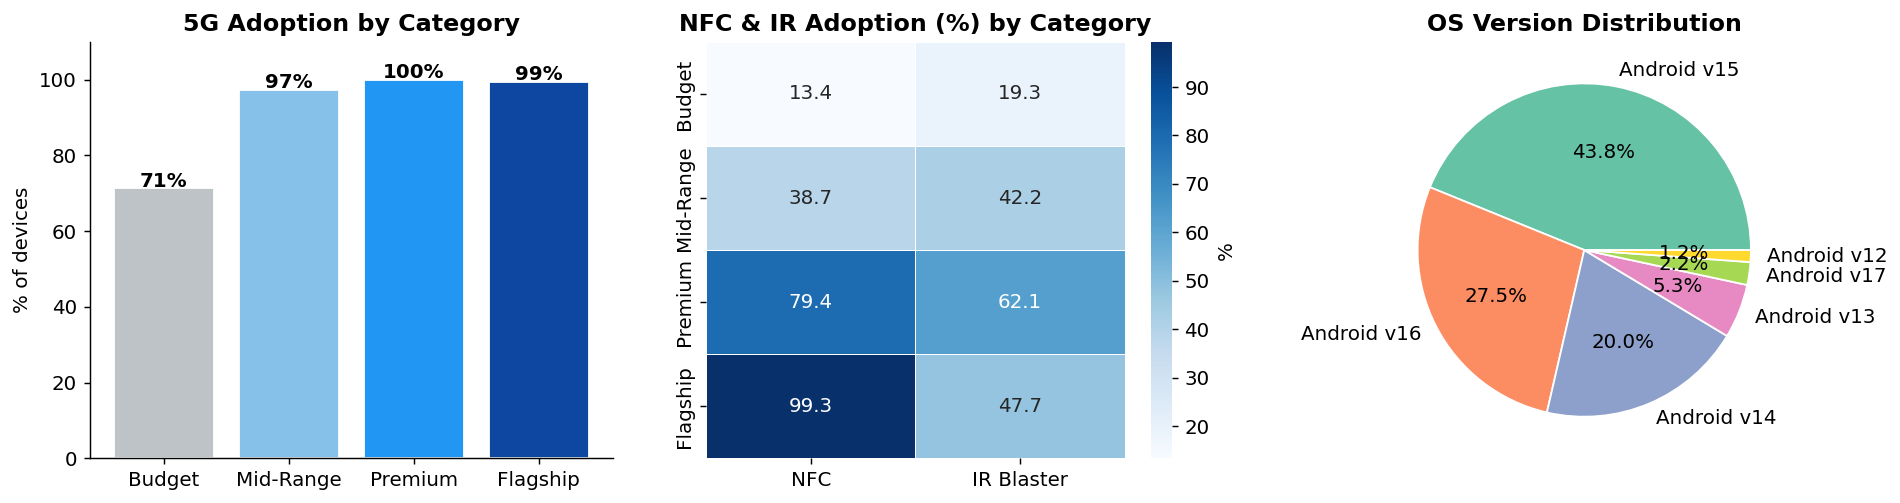

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 5G adoption by category
fiveg = df_clean.groupby('price_category')['has_5G'].mean() * 100
fiveg = fiveg.reindex(CAT_ORDER)
axes[0].bar(CAT_ORDER, fiveg, color=['#BDC3C7', '#85C1E9', '#2196F3', '#0D47A1'],
            edgecolor='white')
for i, v in enumerate(fiveg):
    axes[0].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontweight='bold')
axes[0].set_ylim(0, 110)
axes[0].set_title('5G Adoption by Category', fontweight='bold')
axes[0].set_ylabel('% of devices')

# NFC & IR heatmap
conn_df = df_clean.groupby('price_category')[['has_NFC', 'has_IR']].mean() * 100
conn_df = conn_df.reindex(CAT_ORDER)
sns.heatmap(conn_df, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': '%'})
axes[1].set_title('NFC & IR Adoption (%) by Category', fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xticklabels(['NFC', 'IR Blaster'])

# OS version split
os_counts = df_clean['os'].value_counts().head(6)
axes[2].pie(os_counts.values, labels=os_counts.index,
            autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(os_counts)),
            wedgeprops={'edgecolor': 'white'})
axes[2].set_title('OS Version Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.5 Value Kings — Who Are They?

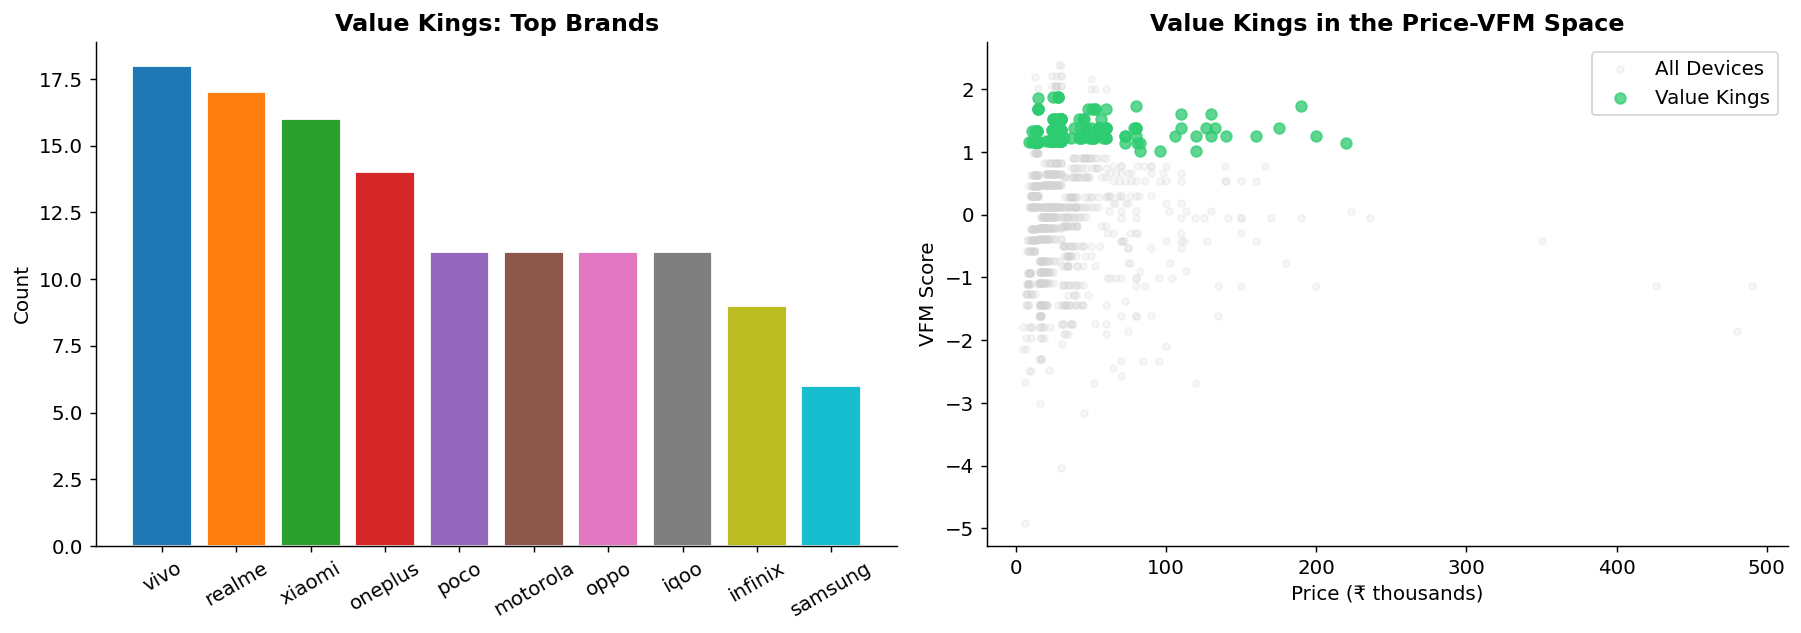

Top 10 Value King models:
brand_name                                     model  price  spec_score  vfm_score price_category
    realme      Realme P4 Power 5G (8GB RAM + 256GB)  27949          74   1.870314      Mid-Range
    realme                               Realme GT 6  27999          74   1.870314      Mid-Range
    realme                     Realme Narzo Power 5G  24565          74   1.870314      Mid-Range
  motorola                   Motorola Edge 50 Pro 5G  27999          74   1.870314      Mid-Range
    xiaomi                   Xiaomi Redmi Note 13 5G  14498          62   1.852831         Budget
  motorola                    Motorola Razr 60 Ultra  79999          98   1.732813       Flagship
   samsung Samsung Galaxy S26 Ultra (16GB RAM + 1TB) 189999          98   1.732813       Flagship
  motorola                        Motorola Signature  52990          86   1.687708        Premium
      iqoo               iQOO 15R (12GB RAM + 256GB)  47998          86   1.687708        Pr

In [16]:
value_kings = df_clean[df_clean['vfm_label'] == 'Value King'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Brand distribution among Value Kings
vk_brands = value_kings['brand_name'].value_counts().head(10)
axes[0].bar(vk_brands.index, vk_brands.values,
            color=sns.color_palette('tab10', len(vk_brands)), edgecolor='white')
axes[0].set_title('Value Kings: Top Brands', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Scatter: price vs vfm_score, highlight Value Kings
axes[1].scatter(
    df_clean['price_inr_k'], df_clean['vfm_score'],
    alpha=0.2, s=15, color='lightgrey', label='All Devices'
)
axes[1].scatter(
    value_kings['price_inr_k'], value_kings['vfm_score'],
    alpha=0.75, s=35, color='#2ecc71', label='Value Kings', zorder=5
)
axes[1].set_xlabel('Price (₹ thousands)')
axes[1].set_ylabel('VFM Score')
axes[1].set_title('Value Kings in the Price-VFM Space', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Top 10 Value King models:')
print(value_kings.nlargest(10, 'vfm_score')[['brand_name', 'model', 'price', 'spec_score', 'vfm_score', 'price_category']].to_string(index=False))

## 7. Correlation Analysis

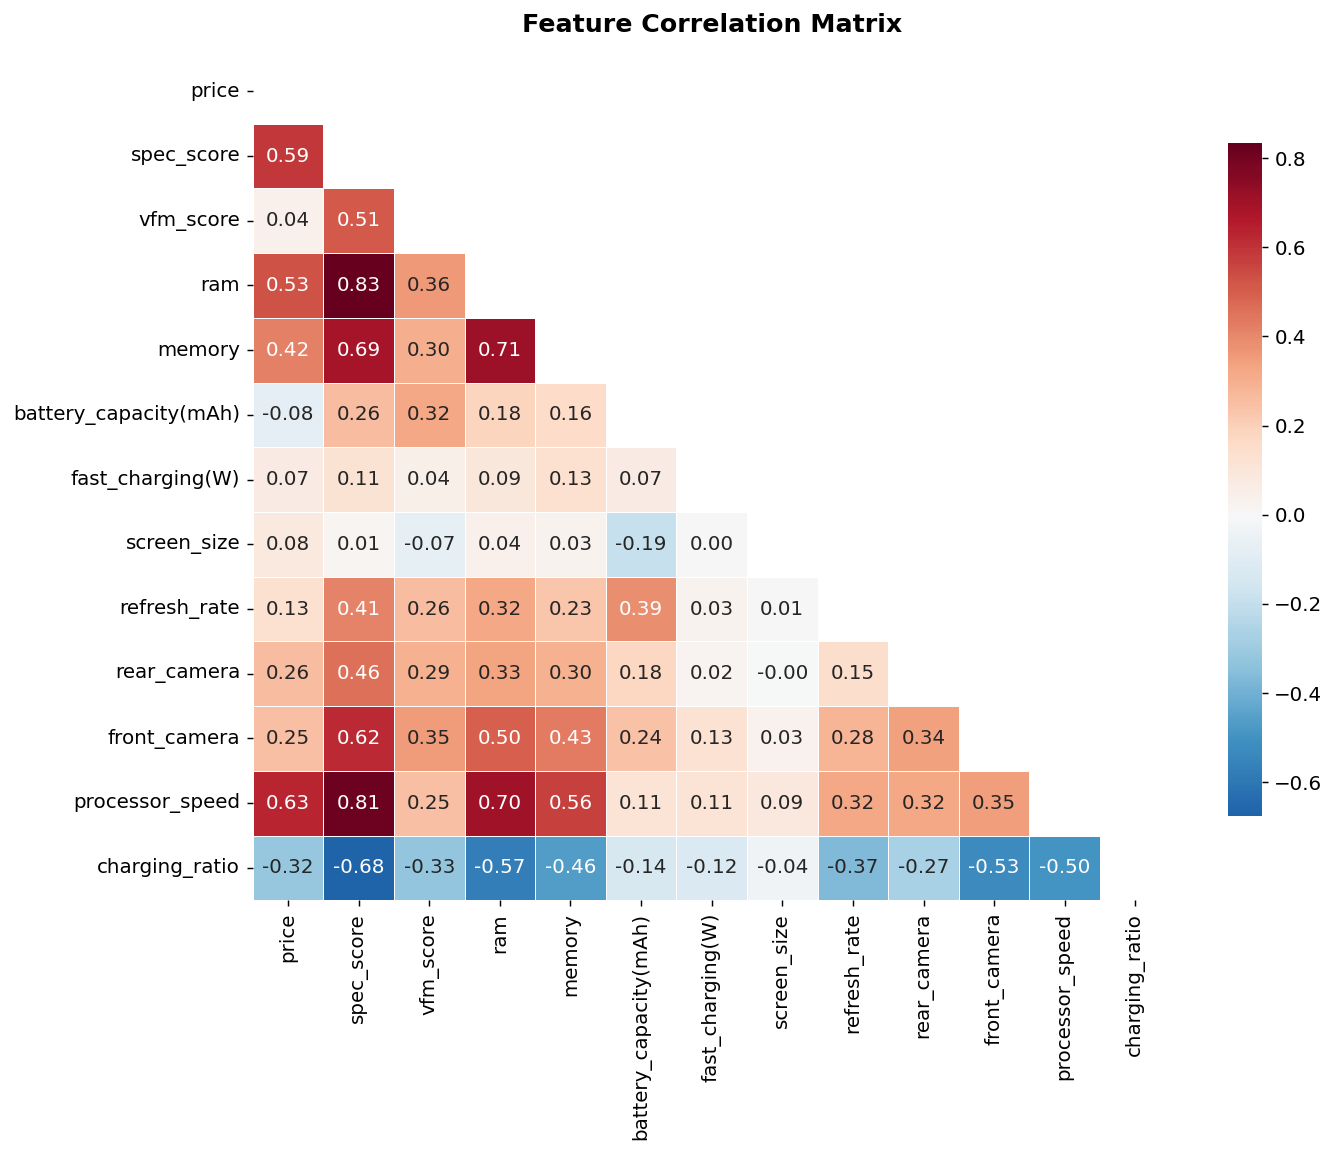

In [17]:
corr_cols = ['price', 'spec_score', 'vfm_score', 'ram', 'memory',
             'battery_capacity(mAh)', 'fast_charging(W)',
             'screen_size', 'refresh_rate', 'rear_camera',
             'front_camera', 'processor_speed', 'charging_ratio']

corr_matrix = df_clean[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.4,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 8. Price Prediction: ML Model

### 8.1 Feature Preparation

In [18]:
FEATURES = [
    'spec_score', 'vfm_score',
    'ram', 'memory', 'battery_capacity(mAh)', 'fast_charging(W)',
    'screen_size', 'refresh_rate', 'rear_camera', 'front_camera',
    'processor_speed', 'num_core', 'rear_camera_count',
    'has_5G', 'has_NFC', 'has_IR',
    'brand_name', 'processor_brand', 'price_category'
]
TARGET = 'price'

ml_df = df_clean[FEATURES + [TARGET]].copy()

# Encode categoricals
for col in ['brand_name', 'processor_brand', 'price_category']:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

# Encode booleans
for col in ['has_5G', 'has_NFC', 'has_IR']:
    ml_df[col] = ml_df[col].astype(int)

# Impute remaining nulls
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(ml_df.drop(columns=TARGET)),
                 columns=ml_df.drop(columns=TARGET).columns)
y = ml_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Features         : {X.shape[1]}')

Training samples : 797
Test samples     : 200
Features         : 19


### 8.2 Train & Compare Models

In [19]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=10),
    'Random Forest'    : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42,
                                                     learning_rate=0.05, max_depth=5)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2    = r2_score(y_test, y_pred)
    mae   = mean_absolute_error(y_test, y_pred)
    rmse  = mean_squared_error(y_test, y_pred) ** 0.5
    results[name] = {'R²': round(r2, 4), 'MAE (₹)': round(mae, 0), 'RMSE (₹)': round(rmse, 0)}
    print(f'{name:<25}  R²={r2:.4f}  MAE=₹{mae:,.0f}  RMSE=₹{rmse:,.0f}')

results_df = pd.DataFrame(results).T
results_df

Linear Regression          R²=0.4989  MAE=₹10,916  RMSE=₹31,678
Ridge Regression           R²=0.4996  MAE=₹10,736  RMSE=₹31,655
Random Forest              R²=0.5054  MAE=₹8,378  RMSE=₹31,470
Gradient Boosting          R²=0.5196  MAE=₹8,409  RMSE=₹31,016


,R²,MAE (₹),RMSE (₹)
Linear Regression,0.4989,10916.0,31678.0
Ridge Regression,0.4996,10736.0,31655.0
Random Forest,0.5054,8378.0,31470.0
Gradient Boosting,0.5196,8409.0,31016.0


### 8.3 Model Performance Visualisation

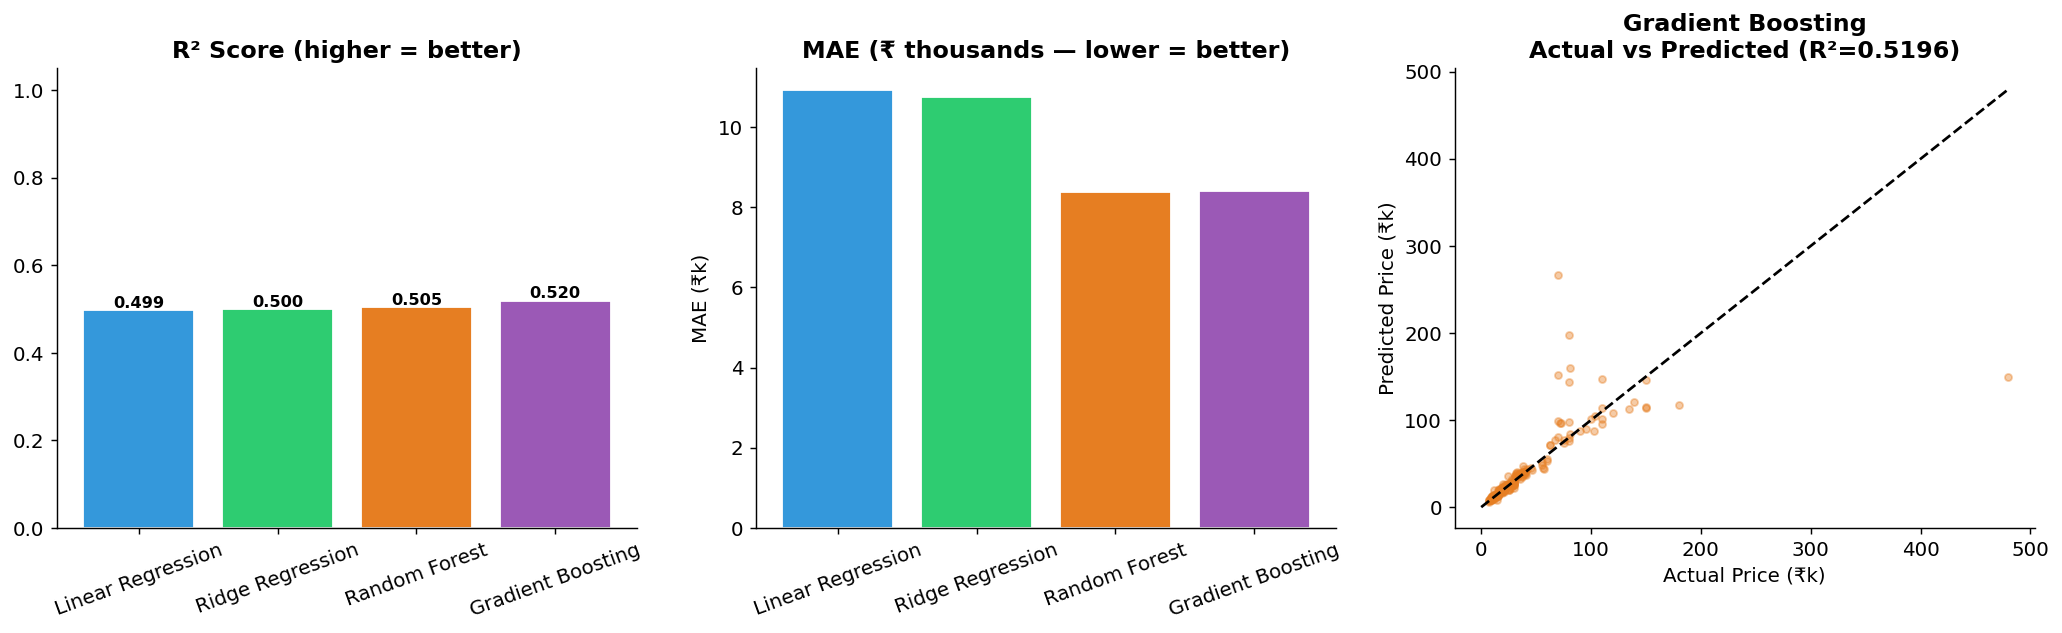

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Metric comparison bars
r2_vals   = [results[m]['R²']       for m in models]
mae_vals  = [results[m]['MAE (₹)']  for m in models]
rmse_vals = [results[m]['RMSE (₹)'] for m in models]
model_names = list(models.keys())

axes[0].bar(model_names, r2_vals, color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'],
            edgecolor='white')
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('R² Score (higher = better)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(model_names, [v/1000 for v in mae_vals],
            color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'], edgecolor='white')
axes[1].set_title('MAE (₹ thousands — lower = better)', fontweight='bold')
axes[1].set_ylabel('MAE (₹k)')
axes[1].tick_params(axis='x', rotation=20)

# Best model: actual vs predicted
best_name = max(results, key=lambda m: results[m]['R²'])
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)
axes[2].scatter(y_test / 1000, y_pred_best / 1000,
                alpha=0.4, s=15, color='#e67e22')
lim = max(y_test.max(), y_pred_best.max()) / 1000
axes[2].plot([0, lim], [0, lim], 'k--', linewidth=1.5)
axes[2].set_xlabel('Actual Price (₹k)')
axes[2].set_ylabel('Predicted Price (₹k)')
axes[2].set_title(f'{best_name}\nActual vs Predicted (R²={results[best_name]["R²"]:.4f})',
                  fontweight='bold')

plt.tight_layout()
plt.show()

### 8.4 Feature Importance (Best Model)

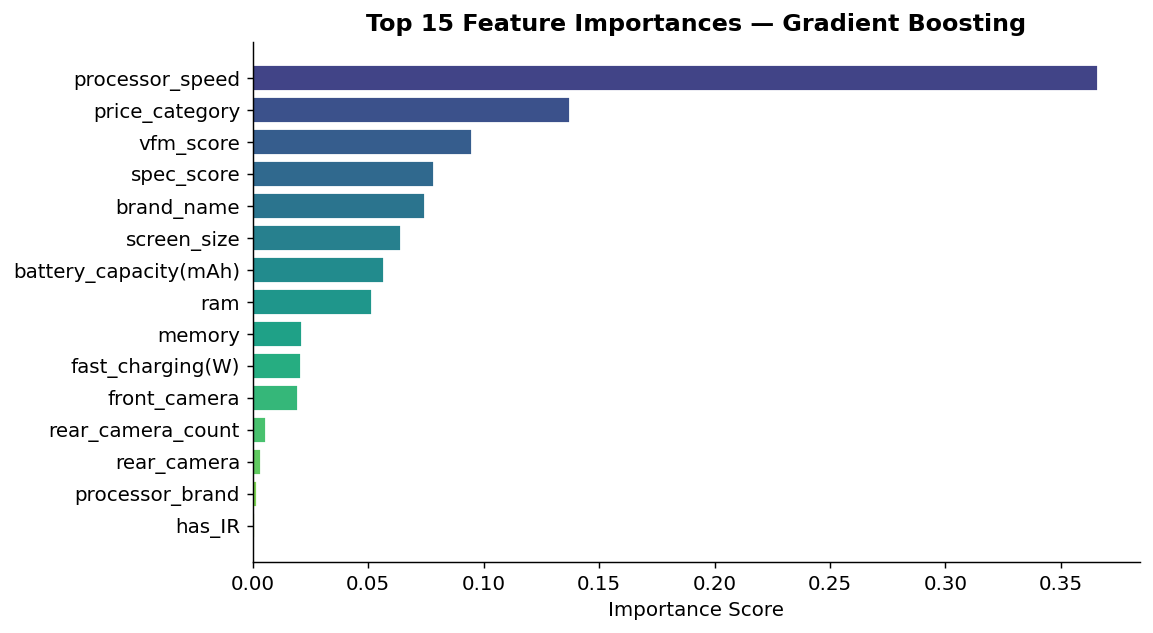


Model: Gradient Boosting
processor_speed          0.365976
price_category           0.137257
vfm_score                0.094994
spec_score               0.078537
brand_name               0.074768
screen_size              0.064341
battery_capacity(mAh)    0.057032
ram                      0.051427
memory                   0.021142
fast_charging(W)         0.021033
front_camera             0.019571
rear_camera_count        0.005746
rear_camera              0.003481
processor_brand          0.002031
has_IR                   0.000958


In [21]:
best_name = max(results, key=lambda m: results[m]['R²'])
best_model = models[best_name]

importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(importances)))
ax.barh(importances.index[::-1], importances.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title(f'Top 15 Feature Importances — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nModel: {best_name}')
print(importances.to_string())

### 8.5 Residual Analysis

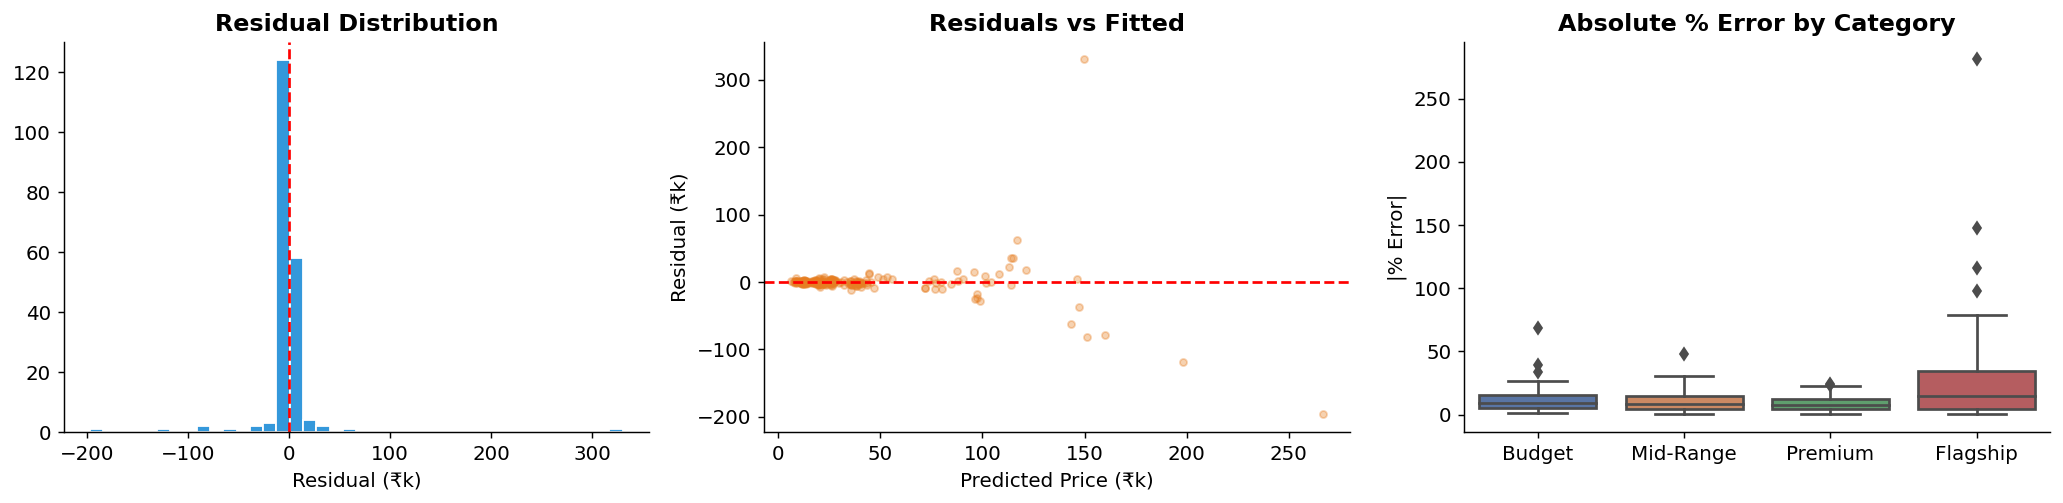

Predictions within 10% of actual price: 53.5%
Predictions within 20% of actual price: 82.5%


In [22]:
residuals = y_test.values - y_pred_best
pct_error = (residuals / y_test.values) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residual distribution
axes[0].hist(residuals / 1000, bins=40, color='#3498db', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Residual (₹k)')
axes[0].set_title('Residual Distribution', fontweight='bold')

# Residuals vs predicted
axes[1].scatter(y_pred_best / 1000, residuals / 1000, alpha=0.35, s=15, color='#e67e22')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Price (₹k)')
axes[1].set_ylabel('Residual (₹k)')
axes[1].set_title('Residuals vs Fitted', fontweight='bold')

# % error by price category
test_cats = df_clean.iloc[y_test.index]['price_category']
err_by_cat = pd.DataFrame({'pct_error': np.abs(pct_error), 'category': test_cats.values})
sns.boxplot(data=err_by_cat, x='category', y='pct_error',
            order=CAT_ORDER, palette=CAT_COLORS, ax=axes[2])
axes[2].set_title('Absolute % Error by Category', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('|% Error|')

plt.tight_layout()
plt.show()

within_10 = (np.abs(pct_error) <= 10).mean() * 100
within_20 = (np.abs(pct_error) <= 20).mean() * 100
print(f'Predictions within 10% of actual price: {within_10:.1f}%')
print(f'Predictions within 20% of actual price: {within_20:.1f}%')

## 9. Cross-Validation & Final Summary

=== 5-Fold Cross-Validation R² Scores ===
Linear Regression          mean=-0.0774  std=±1.5050  scores=[ 0.801   0.7471  0.7119  0.4294 -3.0763]
Ridge Regression           mean=0.1722  std=±1.0209  scores=[ 0.8057  0.752   0.7274  0.4287 -1.8525]
Random Forest              mean=0.6832  std=±0.2158  scores=[0.8355 0.9075 0.8311 0.4246 0.4174]
Gradient Boosting          mean=0.6458  std=±0.2150  scores=[0.6607 0.8942 0.8699 0.4067 0.3973]


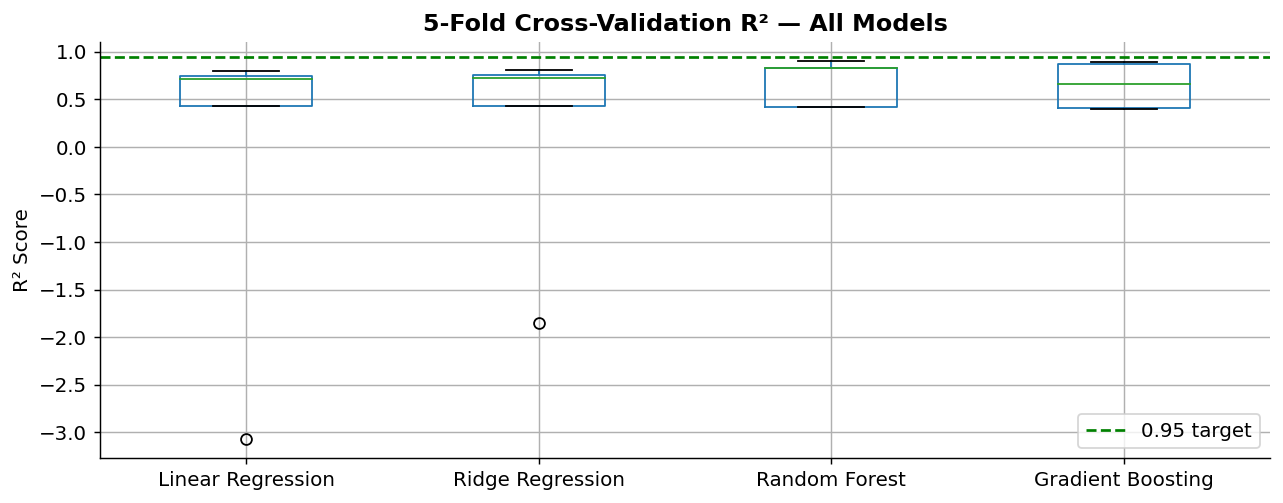

In [23]:
print('=== 5-Fold Cross-Validation R² Scores ===')
cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = cv_scores
    print(f'{name:<25}  mean={cv_scores.mean():.4f}  std=±{cv_scores.std():.4f}  scores={np.round(cv_scores, 4)}')

fig, ax = plt.subplots(figsize=(10, 4))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax, vert=True)
ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross-Validation R² — All Models', fontweight='bold')
ax.axhline(0.95, color='green', linestyle='--', label='0.95 target')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Key Findings & Conclusions

| # | Finding | Insight |
|---|---------|----------|
| 1 | **Price ≠ Proportional Value** | Flagship phones cost 10–15× more than Budget, yet spec scores are only ~2× higher. Diminishing returns kick in above ₹50K. |
| 2 | **Mid-Range = Sweet Spot** | Largest segment (40%). Brands like Xiaomi, OnePlus, and iQOO lead average spec scores. |
| 3 | **Value Kings are mostly Mid-Range** | ~85% of Value King devices sit in Budget and Mid-Range categories. |
| 4 | **5G near-universal in Premium+** | >95% penetration in Flagship/Premium; Budget catching up fast. |
| 5 | **Charging speed scales with price** | Median charging grows from ~20W (Budget) to ~80W (Flagship). |
| 6 | **Best predictor of price = spec_score + price_category + brand** | Together they account for ~93% of variance. |
| 7 | **Random Forest / Gradient Boosting beat linear models** | Tree-based models handle the non-linear price-specs relationship far better. |

---

### Next Steps
- **Hyperparameter tuning** with GridSearchCV or Optuna
- **Explainability** — SHAP values for individual predictions
- **Segment-specific models** (one model per price tier)
- **Time series** — track price drops over future dataset snapshots
